<a href="https://colab.research.google.com/github/clarshine/matkul-visualisasi-data/blob/main/Autoregressive_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)

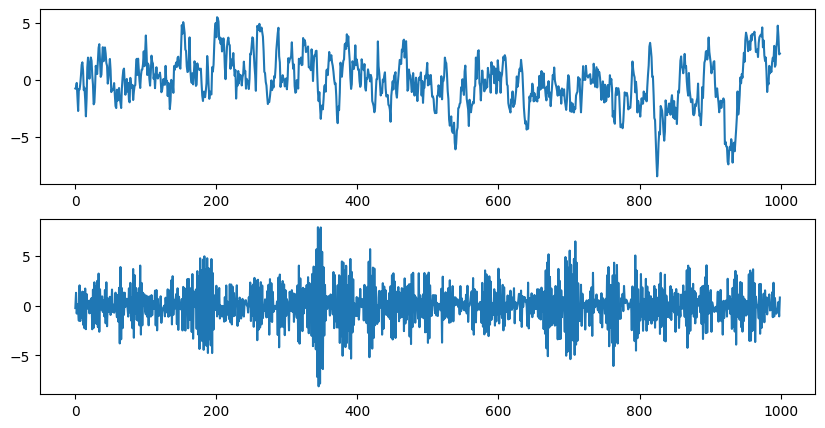

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess

# Plot 1: AR parameter = +0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1, -0.9])
ma1 = np.array([1])
AR_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = AR_object1.generate_sample(nsample=1000)
plt.plot(simulated_data_1);

# Plot 2: AR parameter = -0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1, 0.9])
ma2 = np.array([1])
AR_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = AR_object2.generate_sample(nsample=1000)
plt.plot(simulated_data_2);

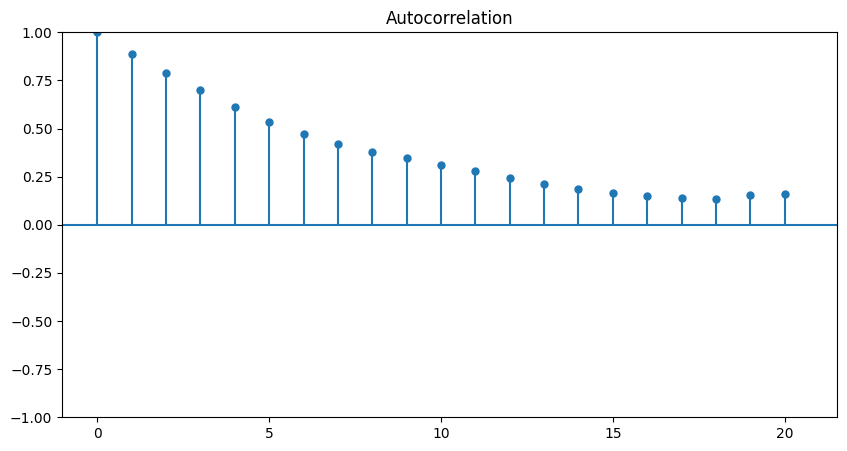

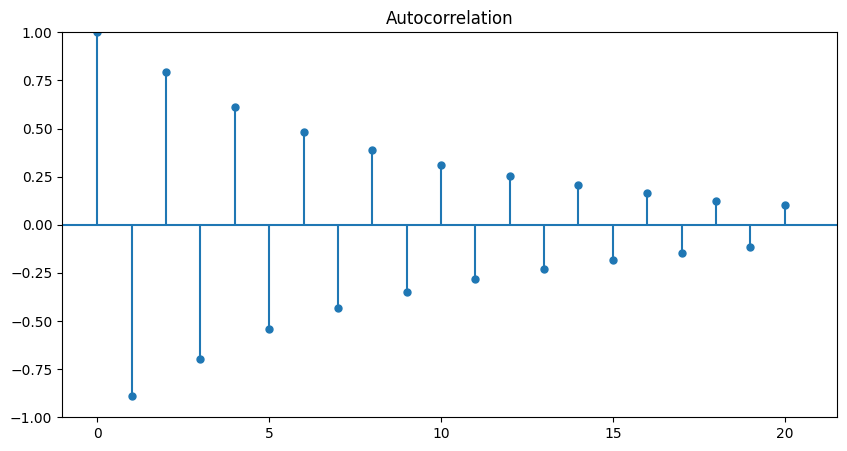

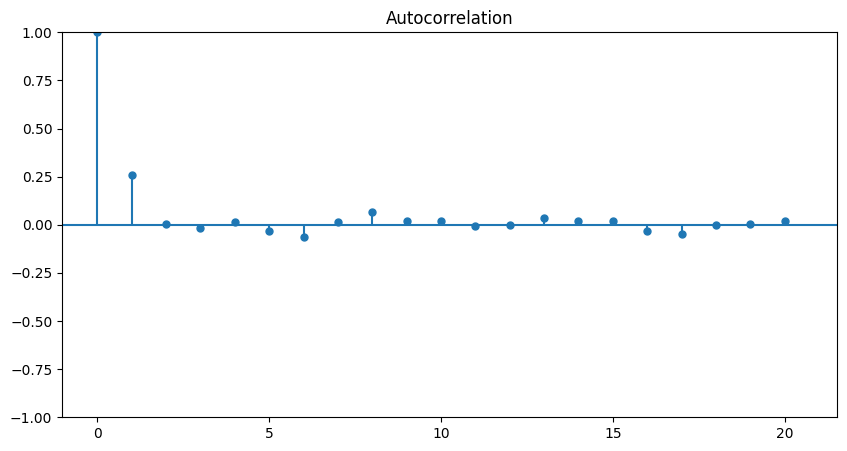

In [3]:
from statsmodels.graphics.tsaplots import plot_acf

# AR parameter = +0.3
ar3 = np.array([1, -0.3])
ma3 = np.array([1])
AR_object3 = ArmaProcess(ar3, ma3)
simulated_data_3 = AR_object3.generate_sample(nsample=1000)

# Plot 1: AR parameter = +0.9
plot_acf(simulated_data_1, alpha=1, lags=20);

# Plot 2: AR parameter = -0.9
plot_acf(simulated_data_2, alpha=1, lags=20);

# Plot 3: AR parameter = +0.3
plot_acf(simulated_data_3, alpha=1, lags=20);

In [8]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Fit AR(1) model
mod = ARIMA(simulated_data_1, order=(1, 0, 0))
res = mod.fit()

# Summary hasil
print(res.summary())

# Tampilkan estimasi konstanta dan phi
print("When the true phi=0.9, the estimate of phi (and the constant) are:")
print(res.params)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1408.758
Date:                Sun, 29 Jun 2025   AIC                           2823.516
Time:                        01:35:53   BIC                           2838.240
Sample:                             0   HQIC                          2829.112
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0886      0.282     -0.314      0.753      -0.641       0.464
ar.L1          0.8888      0.015     61.095      0.000       0.860       0.917
sigma2         0.9783      0.044     22.416      0.0

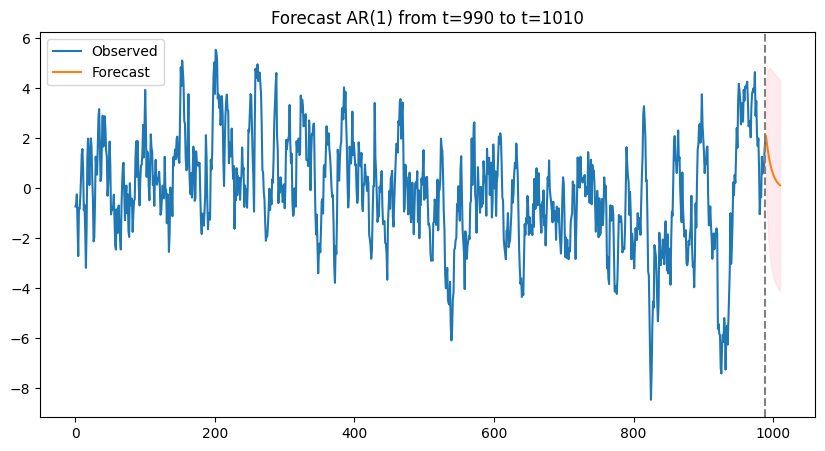

In [11]:
# Forecast ke depan dari indeks 990 sampai 1010 (21 langkah)
start = 990
steps = 1010 - 990 + 1
forecast_result = res.get_forecast(steps=steps)
mean_forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Plot (setara dengan res.plot_predict)
plt.figure(figsize=(10, 5))
plt.plot(simulated_data_1[:start], label="Observed")
plt.plot(range(start, start + steps), mean_forecast, label="Forecast")
plt.fill_between(range(start, start + steps),
                 conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.axvline(start - 1, color='gray', linestyle='--')  # garis batas forecast
plt.legend()
plt.title("Forecast AR(1) from t=990 to t=1010")
plt.show()

In [12]:
bonds = pd.read_csv('daily_rates.csv', index_col=0)
bonds.index = pd.to_datetime(bonds.index, format="%Y-%m-%d")
bonds.head()

,US10Y
DATE,
1962-01-02,4.06
1962-01-03,4.03
1962-01-04,3.99
1962-01-05,4.02
1962-01-08,4.03


In [14]:
interest_rate_data = bonds.resample(rule='A').last()
interest_rate_data.head()

/tmp/ipython-input-14-1824167158.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  interest_rate_data = bonds.resample(rule='A').last()


,US10Y
DATE,
1962-12-31,3.85
1963-12-31,4.14
1964-12-31,4.21
1965-12-31,4.65
1966-12-31,4.64


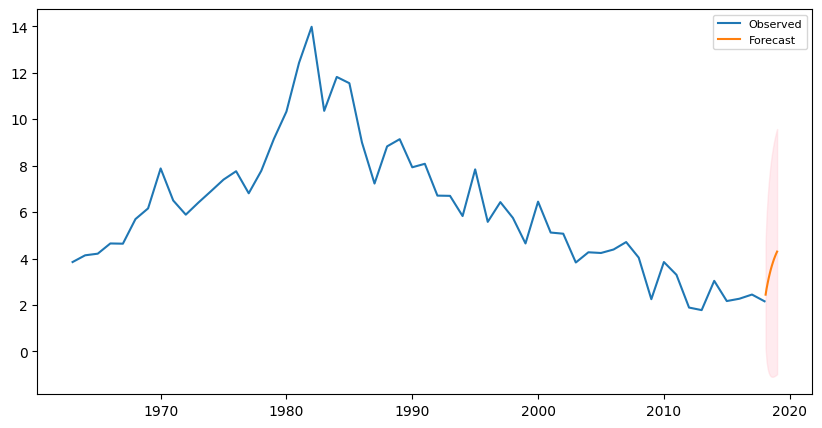

In [19]:
# Forecast interest rates using an AR(1) model
mod = ARIMA(interest_rate_data, order=(1, 0, 0))
res = mod.fit()

# Forecast
steps = 12
forecast_result = res.get_forecast(steps=steps)
forecast_index = pd.date_range(interest_rate_data.index[-1], periods=steps + 1, freq='ME')[1:]
conf_int = forecast_result.conf_int()

# Plot the original series and the forecasted series
plt.figure(figsize=(10, 5))
plt.plot(interest_rate_data, label='Observed')
plt.plot(forecast_index, forecast_result.predicted_mean, label='Forecast')
plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.legend(fontsize=8)
plt.savefig('arma_forecast.png')

In [20]:
simulated_data = np.array([5.        , 4.77522278, 5.60354317, 5.96406402, 5.97965372,
       6.02771876, 5.5470751 , 5.19867084, 5.01867859, 5.50452928,
       5.89293842, 4.6220103 , 5.06137835, 5.33377592, 5.09333293,
       5.37389022, 4.9657092 , 5.57339283, 5.48431854, 4.68588587,
       5.25218625, 4.34800798, 4.34544412, 4.72362568, 4.12582912,
       3.54622069, 3.43999885, 3.77116252, 3.81727011, 4.35256176,
       4.13664247, 3.8745768 , 4.01630403, 3.71276593, 3.55672457,
       3.07062647, 3.45264414, 3.28123729, 3.39193866, 3.02947806,
       3.88707349, 4.28776889, 3.47360734, 3.33260631, 3.09729579,
       2.94652178, 3.50079273, 3.61020341, 4.23021143, 3.94289347,
       3.58422345, 3.18253962, 3.26132564, 3.19777388, 3.43527681,
       3.37204482])

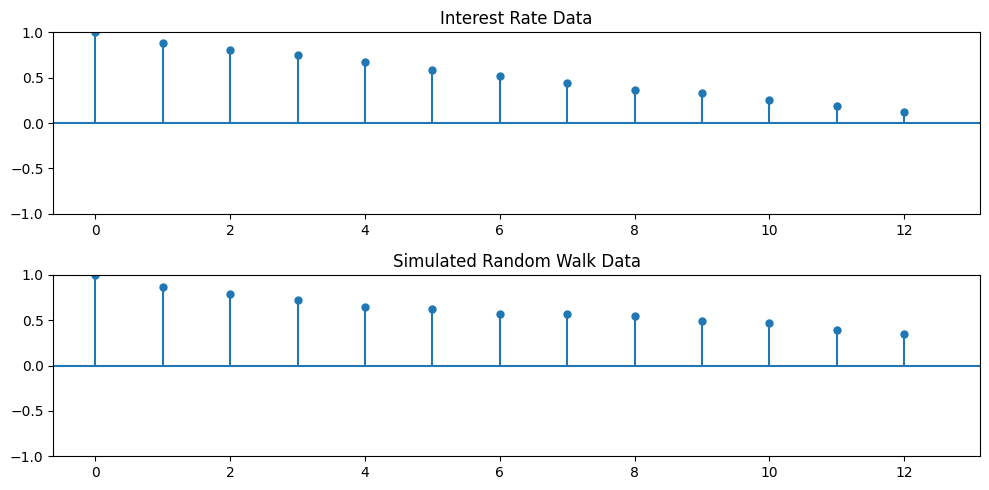

In [21]:
# Plot the interest rate series and the simulated random walk series side-by-side
fig, axes = plt.subplots(2, 1)

# Plot the autocorrelation of the interest rate series in the top plot
fig = plot_acf(interest_rate_data, alpha=1, lags=12, ax=axes[0]);

# Plot the autocorrelation of the simulated random walk series in the bottom plot
fig = plot_acf(simulated_data, alpha=1, lags=12, ax=axes[1]);

# Label axes
axes[0].set_title("Interest Rate Data");
axes[1].set_title("Simulated Random Walk Data");

plt.tight_layout()

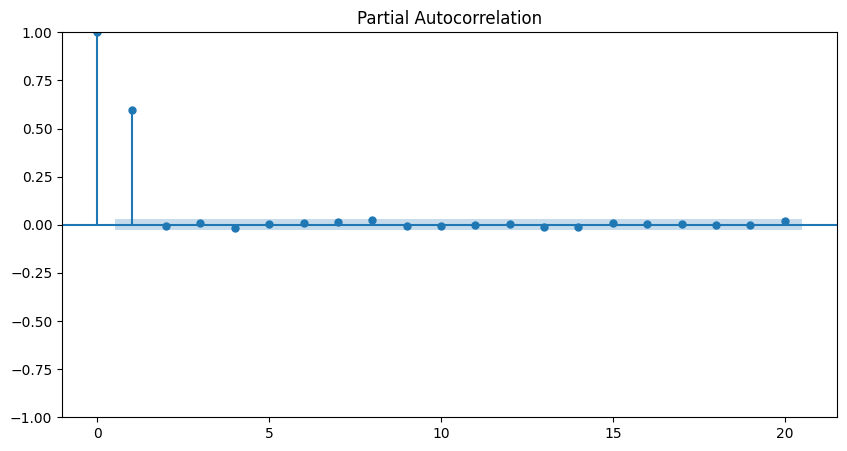

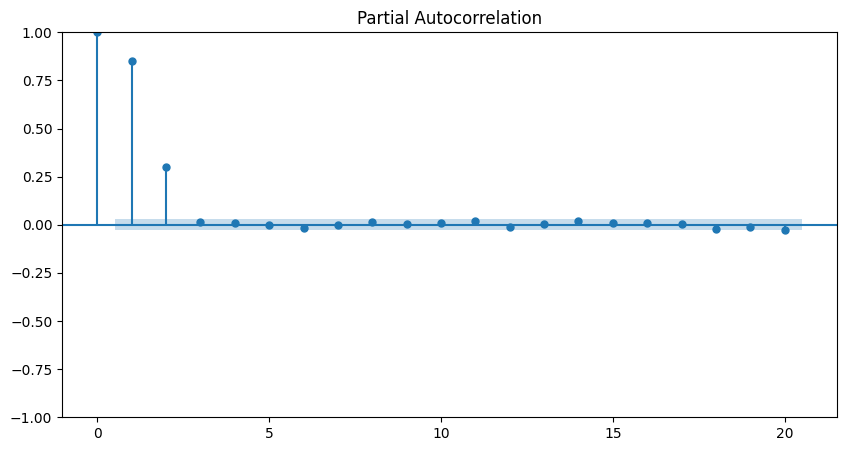

In [22]:
from statsmodels.graphics.tsaplots import plot_pacf

# Simulate AR(1) with phi=+0.6
ma = np.array([1])
ar = np.array([1, -0.6])
AR_object = ArmaProcess(ar, ma)
simulated_data_1 = AR_object.generate_sample(nsample=5000)

# Plot PACF for AR(1)
plot_pacf(simulated_data_1, lags=20);

# simulated AR(2) with phi1=+0.6, phi2=+0.3
ma = np.array([1])
ar = np.array([1, -0.6, -0.3])
AR_object = ArmaProcess(ar, ma)
simulated_data_2 = AR_object.generate_sample(nsample=5000)

# Plot PACF for AR(2)
plot_pacf(simulated_data_2, lags=20);

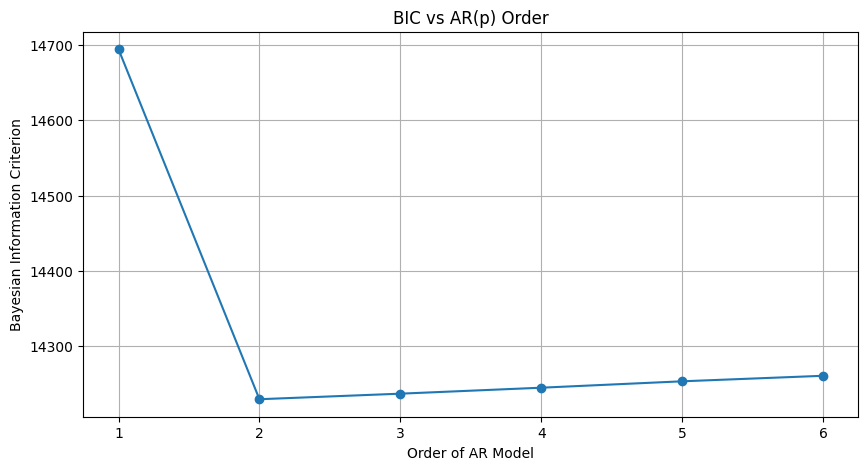

In [25]:
# Fit the data to an AR(p) for p = 0, ..., 6, and save the BIC
BIC = np.zeros(7)

for p in range(7):
    mod = ARIMA(simulated_data_2, order=(p, 0, 0))
    res = mod.fit()
    BIC[p] = res.bic

# Plot the BIC as a function of p
plt.plot(range(1, 7), BIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Bayesian Information Criterion')
plt.title('BIC vs AR(p) Order')
plt.grid(True)
plt.show()
